In [14]:
%pip install -q "transformers>=4.45,<6" "datasets>=3,<5" "accelerate>=1,<2" "nltk>=3.9" "scikit-learn>=1.4" "matplotlib>=3.8" tqdm


In [15]:
import json
import math
import os
import pickle
import random
import shutil
import time
import urllib.request
import zipfile
from collections import Counter
from contextlib import nullcontext
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import numpy as np
import torch
import torch.nn.functional as F
from datasets import load_dataset
from sklearn.decomposition import TruncatedSVD
from torch import nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import BatchEncoding, PretrainedConfig, PreTrainedModel, TrainingArguments
from transformers.modeling_outputs import CausalLMOutput

# Recent NLTK versions use punkt_tab; older ones use punkt. Downloading both is harmless.
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Python ready")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python ready
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [17]:
RUN_MODE = "full"
USE_GOOGLE_DRIVE = False

WORK_DIR = Path("/content/a1_rnn_lm")
WORK_DIR.mkdir(parents=True, exist_ok=True)

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    OUTPUT_DIR = Path("/content/drive/MyDrive/A1_RNN_LM_outputs")
else:
    OUTPUT_DIR = WORK_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if RUN_MODE == "prototype":
    HP = {
        "max_voc_size": 10_000,
        "model_max_length": 80,
        "max_train_examples": 4_000,
        "max_val_examples": 1_000,
        "embedding_size": 128,
        "hidden_size": 256,
        "num_layers": 1,
        "dropout": 0.0,
        "epochs": 1,
        "train_batch_size": 64,
        "eval_batch_size": 64,
        "learning_rate": 2e-3,
    }
elif RUN_MODE == "full":
    HP = {
        "max_voc_size": 20_000,
        "model_max_length": 96,
        "max_train_examples": None,
        "max_val_examples": None,
        "embedding_size": 256,
        "hidden_size": 512,
        "num_layers": 2,
        "dropout": 0.2,
        "epochs": 3,
        "train_batch_size": 32,
        "eval_batch_size": 64,
        "learning_rate": 1e-3,
    }
else:
    raise ValueError("RUN_MODE must be 'prototype' or 'full'.")

print("Mode:", RUN_MODE)
print(json.dumps(HP, indent=2))
print("Outputs:", OUTPUT_DIR)


Mode: full
{
  "max_voc_size": 20000,
  "model_max_length": 96,
  "max_train_examples": null,
  "max_val_examples": null,
  "embedding_size": 256,
  "hidden_size": 512,
  "num_layers": 2,
  "dropout": 0.2,
  "epochs": 3,
  "train_batch_size": 32,
  "eval_batch_size": 64,
  "learning_rate": 0.001
}
Outputs: /content/a1_rnn_lm/outputs


## 0.1 Obtain the assignment data

The cell first checks for `/content/a1_1.zip`; if it is absent, it downloads the official archive. It extracts the archive and discovers the directory containing both `train.txt` and `val.txt`.


In [18]:
ARCHIVE_URL = "https://www.cse.chalmers.se/~richajo/waspnlp2026/a1_1.zip"
uploaded_archive = Path("/content/a1_1.zip")
archive_path = uploaded_archive if uploaded_archive.exists() else WORK_DIR / "a1_1.zip"

if not archive_path.exists():
    print("Downloading the official assignment archive...")
    urllib.request.urlretrieve(ARCHIVE_URL, archive_path)

extract_dir = WORK_DIR / "assignment_data"
if not extract_dir.exists():
    extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(archive_path) as zf:
        zf.extractall(extract_dir)

candidates = [p.parent for p in extract_dir.rglob("train.txt") if (p.parent / "val.txt").exists()]
if not candidates:
    raise FileNotFoundError("Could not find train.txt and val.txt after extracting the archive.")

DATA_DIR = candidates[0]
TRAIN_FILE = DATA_DIR / "train.txt"
VAL_FILE = DATA_DIR / "val.txt"

print("Training file:", TRAIN_FILE, f"({TRAIN_FILE.stat().st_size / 2**20:.1f} MiB)")
print("Validation file:", VAL_FILE, f"({VAL_FILE.stat().st_size / 2**20:.1f} MiB)")


Training file: /content/a1_rnn_lm/assignment_data/a1_1/train.txt (62.0 MiB)
Validation file: /content/a1_rnn_lm/assignment_data/a1_1/val.txt (7.9 MiB)


# Part 1 - Tokenization

Word splitting converts a paragraph into string tokens. Tokenization then adds special symbols, maps strings to integer IDs, truncates long sequences, pads batches, and builds an attention mask.


In [19]:
def lowercase_tokenizer(text):
    # Split English text with NLTK and lowercase every token.
    if not isinstance(text, str):
        raise TypeError(f"Expected a string, received {type(text).__name__}.")
    return [token.lower() for token in nltk.word_tokenize(text)]


print(lowercase_tokenizer("Let's test!!"))


['let', "'s", 'test', '!', '!']


In [20]:
class A1Tokenizer:
    # A minimal HuggingFace-like tokenizer for this assignment.

    def __init__(
        self,
        str_to_int,
        tokenize_fun=lowercase_tokenizer,
        model_max_length=None,
        pad_token="<PAD>",
        unk_token="<UNK>",
        bos_token="<BOS>",
        eos_token="<EOS>",
    ):
        self.str_to_int = dict(str_to_int)
        self.int_to_str = {idx: token for token, idx in self.str_to_int.items()}
        self.tokenize_fun = tokenize_fun
        self.model_max_length = model_max_length

        self.pad_token = pad_token
        self.unk_token = unk_token
        self.bos_token = bos_token
        self.eos_token = eos_token
        self.pad_token_id = self.str_to_int[pad_token]
        self.unk_token_id = self.str_to_int[unk_token]
        self.bos_token_id = self.str_to_int[bos_token]
        self.eos_token_id = self.str_to_int[eos_token]

        if model_max_length is not None and model_max_length < 2:
            raise ValueError("model_max_length must allow at least BOS and EOS (>= 2).")

    @staticmethod
    def _normalise_text_input(texts):
        # Supports one string, a list of strings, a dataset-style {'text': ...} mapping,
        # and the extra nesting shown in the assignment's example.
        if isinstance(texts, str):
            return [texts]
        if isinstance(texts, dict) and "text" in texts:
            texts = texts["text"]
        if isinstance(texts, (list, tuple)) and len(texts) == 1 and isinstance(texts[0], (list, tuple)):
            texts = texts[0]
        if not isinstance(texts, (list, tuple)) or not all(isinstance(x, str) for x in texts):
            raise TypeError("texts must be a string or a sequence of strings.")
        return list(texts)

    def encode(self, text, truncation=False):
        tokens = self.tokenize_fun(text)
        if truncation and self.model_max_length is not None:
            tokens = tokens[: self.model_max_length - 2]
        ids = [self.bos_token_id]
        ids.extend(self.str_to_int.get(token, self.unk_token_id) for token in tokens)
        ids.append(self.eos_token_id)
        return ids

    def __call__(self, texts, truncation=False, padding=False, return_tensors=None):
        if return_tensors not in (None, "pt"):
            raise ValueError("return_tensors must be None or 'pt'.")

        texts = self._normalise_text_input(texts)
        input_ids = [self.encode(text, truncation=truncation) for text in texts]

        if padding:
            target_length = self.model_max_length if padding == "max_length" else max(map(len, input_ids), default=0)
            if self.model_max_length is not None and truncation:
                target_length = min(target_length, self.model_max_length)
            input_ids = [ids + [self.pad_token_id] * (target_length - len(ids)) for ids in input_ids]

        attention_mask = [[int(token_id != self.pad_token_id) for token_id in ids] for ids in input_ids]

        if return_tensors == "pt":
            lengths = {len(ids) for ids in input_ids}
            if len(lengths) > 1:
                raise ValueError("Unequal sequence lengths cannot form a tensor; set padding=True.")
            input_ids = torch.tensor(input_ids, dtype=torch.long)
            attention_mask = torch.tensor(attention_mask, dtype=torch.long)

        return BatchEncoding({"input_ids": input_ids, "attention_mask": attention_mask})

    def __len__(self):
        return len(self.str_to_int)

    def save(self, filename):
        filename = Path(filename)
        filename.parent.mkdir(parents=True, exist_ok=True)
        with filename.open("wb") as handle:
            pickle.dump(self, handle)

    @staticmethod
    def from_file(filename):
        with Path(filename).open("rb") as handle:
            return pickle.load(handle)


def build_tokenizer(
    train_file,
    tokenize_fun=lowercase_tokenizer,
    max_voc_size=None,
    model_max_length=None,
    pad_token="<PAD>",
    unk_token="<UNK>",
    bos_token="<BOS>",
    eos_token="<EOS>",
    max_paragraphs=None,
):
    # Build a frequency-truncated vocabulary from non-empty training paragraphs.
    special_tokens = [pad_token, unk_token, bos_token, eos_token]
    if len(set(special_tokens)) != 4:
        raise ValueError("The four special tokens must be different.")
    if max_voc_size is not None and max_voc_size < len(special_tokens):
        raise ValueError("max_voc_size must be at least 4.")

    counts = Counter()
    paragraphs_seen = 0
    with Path(train_file).open("r", encoding="utf-8") as handle:
        for line in tqdm(handle, desc="Counting training tokens"):
            text = line.strip()
            if not text:
                continue
            counts.update(tokenize_fun(text))
            paragraphs_seen += 1
            if max_paragraphs is not None and paragraphs_seen >= max_paragraphs:
                break

    # Special strings are reserved even if an identical literal happens to occur in the corpus.
    for token in special_tokens:
        counts.pop(token, None)

    keep = None if max_voc_size is None else max_voc_size - len(special_tokens)
    vocabulary_tokens = [token for token, _ in counts.most_common(keep)]
    str_to_int = {token: idx for idx, token in enumerate(special_tokens + vocabulary_tokens)}

    tokenizer = A1Tokenizer(
        str_to_int=str_to_int,
        tokenize_fun=tokenize_fun,
        model_max_length=model_max_length,
        pad_token=pad_token,
        unk_token=unk_token,
        bos_token=bos_token,
        eos_token=eos_token,
    )
    tokenizer.vocabulary_counts = counts
    tokenizer.paragraphs_seen = paragraphs_seen
    return tokenizer


In [21]:
TOKENIZER_FILE = OUTPUT_DIR / f"tokenizer_{RUN_MODE}.pkl"

if TOKENIZER_FILE.exists():
    tokenizer = A1Tokenizer.from_file(TOKENIZER_FILE)
    print("Loaded cached tokenizer:", TOKENIZER_FILE)
else:
    tokenizer = build_tokenizer(
        TRAIN_FILE,
        max_voc_size=HP["max_voc_size"],
        model_max_length=HP["model_max_length"],
        max_paragraphs=HP["max_train_examples"],
    )
    tokenizer.save(TOKENIZER_FILE)
    print("Saved tokenizer:", TOKENIZER_FILE)

print("Vocabulary size:", len(tokenizer))
print("Special-token IDs:", {
    "PAD": tokenizer.pad_token_id,
    "UNK": tokenizer.unk_token_id,
    "BOS": tokenizer.bos_token_id,
    "EOS": tokenizer.eos_token_id,
})


Counting training tokens: 0it [00:00, ?it/s]

Saved tokenizer: /content/a1_rnn_lm/outputs/tokenizer_full.pkl
Vocabulary size: 20000
Special-token IDs: {'PAD': 0, 'UNK': 1, 'BOS': 2, 'EOS': 3}


In [22]:
# Task 1 sanity checks
assert len(tokenizer) <= HP["max_voc_size"]
assert len({tokenizer.pad_token_id, tokenizer.unk_token_id, tokenizer.bos_token_id, tokenizer.eos_token_id}) == 4
assert "the" in tokenizer.str_to_int and "and" in tokenizer.str_to_int

test_word = "the"
assert tokenizer.int_to_str[tokenizer.str_to_int[test_word]] == test_word

test_batch = tokenizer(
    ["This is a test.", "Another test."],
    return_tensors="pt",
    padding=True,
    truncation=True,
)
print(test_batch)
assert test_batch["input_ids"].ndim == 2
assert test_batch["input_ids"].shape == test_batch["attention_mask"].shape
assert (test_batch["attention_mask"][:, -1] == torch.tensor([1, 0])).all()
print("Tokenizer sanity checks passed.")


{'input_ids': tensor([[  2,  35,  14,  11, 965,   6,   3],
        [  2, 153, 965,   6,   3,   0,   0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 0, 0]])}
Tokenizer sanity checks passed.


# Part 2 - Load the datasets and create batches

HuggingFace Datasets stores the text efficiently in Arrow format. Empty lines are removed. In smoke mode, only a small deterministic prefix is selected; full mode keeps every non-empty paragraph.


In [23]:
dataset = load_dataset(
    "text",
    data_files={"train": str(TRAIN_FILE), "val": str(VAL_FILE)},
)
dataset = dataset.filter(lambda row: bool(row["text"].strip()))

full_sizes = {split: len(dataset[split]) for split in ("train", "val")}
if HP["max_train_examples"] is not None:
    n = min(HP["max_train_examples"], len(dataset["train"]))
    dataset["train"] = dataset["train"].select(range(n))
if HP["max_val_examples"] is not None:
    n = min(HP["max_val_examples"], len(dataset["val"]))
    dataset["val"] = dataset["val"].select(range(n))

print("Full non-empty sizes:", full_sizes)
print("Active sizes:", {split: len(dataset[split]) for split in ("train", "val")})
print("Example:", dataset["train"][0]["text"][:200])

assert 140_000 <= full_sizes["train"] <= 155_000
assert 17_000 <= full_sizes["val"] <= 20_000


Full non-empty sizes: {'train': 147059, 'val': 17874}
Active sizes: {'train': 147059, 'val': 17874}
Example: Anatomy


In [24]:
def collate_examples(examples):
    texts = [example["text"] for example in examples]
    encoded = tokenizer(texts, truncation=True, padding=True, return_tensors="pt")
    labels = encoded["input_ids"].clone()
    labels[labels == tokenizer.pad_token_id] = -100
    encoded["labels"] = labels
    return encoded


demo_loader = DataLoader(dataset["train"], batch_size=4, shuffle=True, collate_fn=collate_examples)
demo_batch = next(iter(demo_loader))
print({name: tuple(value.shape) for name, value in demo_batch.items()})
print("First input row:", demo_batch["input_ids"][0, :20])
print("First label row:", demo_batch["labels"][0, :20])


{'input_ids': (4, 96), 'attention_mask': (4, 96), 'labels': (4, 96)}
First input row: tensor([   2,    1, 4019,   17,    1,    1,   16,    5,  467,   10, 1427,    9,
           4,  264,  112,    5,   36, 3948,    1,   22])
First label row: tensor([   2,    1, 4019,   17,    1,    1,   16,    5,  467,   10, 1427,    9,
           4,  264,  112,    5,   36, 3948,    1,   22])


# Part 3 - Define the recurrent language model and its loss

Tensor flow through the network:

- input IDs: `(batch, sequence)`
- embeddings: `(batch, sequence, embedding_size)`
- LSTM outputs: `(batch, sequence, hidden_size)`
- vocabulary logits: `(batch, sequence, vocabulary_size)`

The loss aligns the logits at positions `0...N-2` with labels at positions `1...N-1`, because each token position predicts the following token.


In [25]:
class A1RNNModelConfig(PretrainedConfig):
    model_type = "a1_rnn_language_model"

    def __init__(
        self,
        vocab_size=0,
        embedding_size=128,
        hidden_size=256,
        num_layers=1,
        dropout=0.0,
        rnn_type="lstm",
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.vocab_size = vocab_size
        self.embedding_size = embedding_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout = dropout
        self.rnn_type = rnn_type


class A1RNNModel(PreTrainedModel):
    config_class = A1RNNModelConfig

    def __init__(self, config):
        super().__init__(config)
        if config.rnn_type.lower() != "lstm":
            raise ValueError("This solution implements the recommended LSTM variant.")

        self.embedding = nn.Embedding(
            config.vocab_size,
            config.embedding_size,
            padding_idx=config.pad_token_id,
        )
        self.rnn = nn.LSTM(
            input_size=config.embedding_size,
            hidden_size=config.hidden_size,
            num_layers=config.num_layers,
            dropout=config.dropout if config.num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.unembedding = nn.Linear(config.hidden_size, config.vocab_size)
        self.loss_func = nn.CrossEntropyLoss(ignore_index=-100)
        self.post_init()

    def forward(self, input_ids, labels=None, attention_mask=None, **kwargs):
        embedded = self.embedding(input_ids)
        rnn_out, _ = self.rnn(embedded)
        logits = self.unembedding(rnn_out)

        loss = None
        if labels is not None:
            shifted_logits = logits[:, :-1, :].contiguous()
            shifted_labels = labels[:, 1:].contiguous()
            loss = self.loss_func(
                shifted_logits.reshape(-1, shifted_logits.shape[-1]),
                shifted_labels.reshape(-1),
            )

        return CausalLMOutput(loss=loss, logits=logits)


In [26]:
model_config = A1RNNModelConfig(
    vocab_size=len(tokenizer),
    embedding_size=HP["embedding_size"],
    hidden_size=HP["hidden_size"],
    num_layers=HP["num_layers"],
    dropout=HP["dropout"],
    pad_token_id=tokenizer.pad_token_id,
    bos_token_id=tokenizer.bos_token_id,
    eos_token_id=tokenizer.eos_token_id,
)
model = A1RNNModel(model_config)

# Task 3 sanity checks: shape and a finite shifted language-model loss.
small_input = demo_batch["input_ids"][:1]
small_labels = demo_batch["labels"][:1]
with torch.no_grad():
    small_output = model(input_ids=small_input, labels=small_labels)

expected_shape = (1, small_input.shape[1], len(tokenizer))
print("Logit shape:", tuple(small_output.logits.shape), "expected:", expected_shape)
print("Initial loss:", float(small_output.loss))
assert tuple(small_output.logits.shape) == expected_shape
assert torch.isfinite(small_output.loss)

n_parameters = sum(parameter.numel() for parameter in model.parameters())
print(f"Model parameters: {n_parameters:,}")


Logit shape: (1, 96, 20000) expected: (1, 96, 20000)
Initial loss: 9.9034423828125
Model parameters: 19,058,208


# Part 4 - Train the model

The trainer performs the standard optimization cycle: tokenize and mask, forward pass, zero old gradients, backpropagate, optionally clip gradients, and update the parameters with AdamW. Validation uses `model.eval()` and `torch.no_grad()` so dropout is disabled and no gradient graph is stored.


In [27]:
class A1Trainer:
    # A small, transparent trainer with a HuggingFace-like interface.

    def __init__(self, model, args, train_dataset, eval_dataset, tokenizer):
        self.model = model
        self.args = args
        self.train_dataset = train_dataset
        self.eval_dataset = eval_dataset
        self.tokenizer = tokenizer
        self.history = []

        if args.optim != "adamw_torch":
            raise ValueError("This assignment solution expects optim='adamw_torch'.")
        strategy = getattr(args, "eval_strategy", getattr(args, "evaluation_strategy", "epoch"))
        if "epoch" not in str(strategy).lower():
            raise ValueError("This trainer expects evaluation once per epoch.")

    def select_device(self):
        if getattr(self.args, "use_cpu", False):
            return torch.device("cpu")
        if not getattr(self.args, "no_cuda", False) and torch.cuda.is_available():
            return torch.device("cuda")
        mps_backend = getattr(torch.backends, "mps", None)
        if mps_backend is not None and mps_backend.is_available():
            return torch.device("mps")
        return torch.device("cpu")

    def _collate(self, examples):
        texts = [example["text"] if isinstance(example, dict) else str(example) for example in examples]
        encoded = self.tokenizer(texts, truncation=True, padding=True, return_tensors="pt")
        labels = encoded["input_ids"].clone()
        labels[labels == self.tokenizer.pad_token_id] = -100
        encoded["labels"] = labels
        return encoded

    def _loader(self, data, batch_size, shuffle):
        return DataLoader(
            data,
            batch_size=batch_size,
            shuffle=shuffle,
            collate_fn=self._collate,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
        )

    @staticmethod
    def _predicted_token_count(labels):
        # The first label is excluded by the one-step shift in the model.
        return int((labels[:, 1:] != -100).sum().item())

    @torch.no_grad()
    def evaluate(self, loader=None, device=None):
        device = device or self.select_device()
        loader = loader or self._loader(
            self.eval_dataset,
            self.args.per_device_eval_batch_size,
            shuffle=False,
        )
        self.model.eval()
        total_nll = 0.0
        total_tokens = 0

        for batch in tqdm(loader, desc="Validation", leave=False):
            input_ids = batch["input_ids"].to(device, non_blocking=True)
            labels = batch["labels"].to(device, non_blocking=True)
            outputs = self.model(input_ids=input_ids, labels=labels)
            n_tokens = self._predicted_token_count(labels)
            total_nll += float(outputs.loss) * n_tokens
            total_tokens += n_tokens

        mean_loss = total_nll / max(total_tokens, 1)
        perplexity = math.exp(mean_loss) if mean_loss < 50 else float("inf")
        return {"loss": mean_loss, "perplexity": perplexity, "tokens": total_tokens}

    def train(self):
        args = self.args
        device = self.select_device()
        print("Training device:", device)
        self.model.to(device)

        optimizer = torch.optim.AdamW(
            self.model.parameters(),
            lr=args.learning_rate,
            betas=(args.adam_beta1, args.adam_beta2),
            eps=args.adam_epsilon,
            weight_decay=args.weight_decay,
        )
        train_loader = self._loader(
            self.train_dataset,
            args.per_device_train_batch_size,
            shuffle=True,
        )
        val_loader = self._loader(
            self.eval_dataset,
            args.per_device_eval_batch_size,
            shuffle=False,
        )

        use_amp = device.type == "cuda" and bool(getattr(args, "fp16", False))
        scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

        for epoch in range(1, int(args.num_train_epochs) + 1):
            self.model.train()
            total_nll = 0.0
            total_tokens = 0
            started = time.time()

            progress = tqdm(train_loader, desc=f"Epoch {epoch}/{int(args.num_train_epochs)}")
            for step, batch in enumerate(progress, start=1):
                input_ids = batch["input_ids"].to(device, non_blocking=True)
                labels = batch["labels"].to(device, non_blocking=True)
                optimizer.zero_grad(set_to_none=True)

                amp_context = torch.autocast(device_type="cuda", dtype=torch.float16) if use_amp else nullcontext()
                with amp_context:
                    outputs = self.model(input_ids=input_ids, labels=labels)
                    loss = outputs.loss

                if use_amp:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), args.max_grad_norm)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), args.max_grad_norm)
                    optimizer.step()

                n_tokens = self._predicted_token_count(labels)
                total_nll += float(loss.detach()) * n_tokens
                total_tokens += n_tokens
                if step % max(1, args.logging_steps) == 0:
                    progress.set_postfix(train_loss=f"{total_nll / max(total_tokens, 1):.4f}")

            train_loss = total_nll / max(total_tokens, 1)
            validation = self.evaluate(val_loader, device)
            record = {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": validation["loss"],
                "val_perplexity": validation["perplexity"],
                "seconds": time.time() - started,
            }
            self.history.append(record)
            print(json.dumps(record, indent=2))

        model_dir = Path(args.output_dir)
        model_dir.mkdir(parents=True, exist_ok=True)
        self.model.save_pretrained(model_dir)
        self.tokenizer.save(model_dir / "tokenizer.pkl")
        with (model_dir / "training_history.json").open("w", encoding="utf-8") as handle:
            json.dump(self.history, handle, indent=2)
        print("Saved model and history to", model_dir)
        return self.history


In [28]:
MODEL_DIR = OUTPUT_DIR / f"model_{RUN_MODE}"

training_kwargs = dict(
    output_dir=str(MODEL_DIR),
    optim="adamw_torch",
    learning_rate=HP["learning_rate"],
    num_train_epochs=HP["epochs"],
    per_device_train_batch_size=HP["train_batch_size"],
    per_device_eval_batch_size=HP["eval_batch_size"],
    eval_strategy="epoch",
    logging_steps=25,
    weight_decay=0.01,
    max_grad_norm=1.0,
    use_cpu=False,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
    remove_unused_columns=False,
)

# Compatibility with older Transformers releases that used evaluation_strategy.
try:
    training_args = TrainingArguments(**training_kwargs)
except TypeError:
    training_kwargs["evaluation_strategy"] = training_kwargs.pop("eval_strategy")
    training_args = TrainingArguments(**training_kwargs)

trainer = A1Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["val"],
    tokenizer=tokenizer,
)

history = trainer.train()


Training device: cuda


/tmp/ipykernel_546/2357487571.py:100: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Epoch 1/3:   0%|          | 0/4596 [00:00<?, ?it/s]

Validation:   0%|          | 0/280 [00:00<?, ?it/s]

{
  "epoch": 1,
  "train_loss": 5.685919233295267,
  "val_loss": 5.067238764130555,
  "val_perplexity": 158.73541572925873,
  "seconds": 290.47269678115845
}


...

Epoch 3/3:   0%|          | 0/4596 [00:00<?, ?it/s]

Validation:   0%|          | 0/280 [00:00<?, ?it/s]

{
  "epoch": 3,
  "train_loss": 4.57256725869611,
  "val_loss": 4.5812815617390985,
  "val_perplexity": 97.63944503674523,
  "seconds": 286.8801050186157
}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model and history to /content/a1_rnn_lm/outputs/model_full


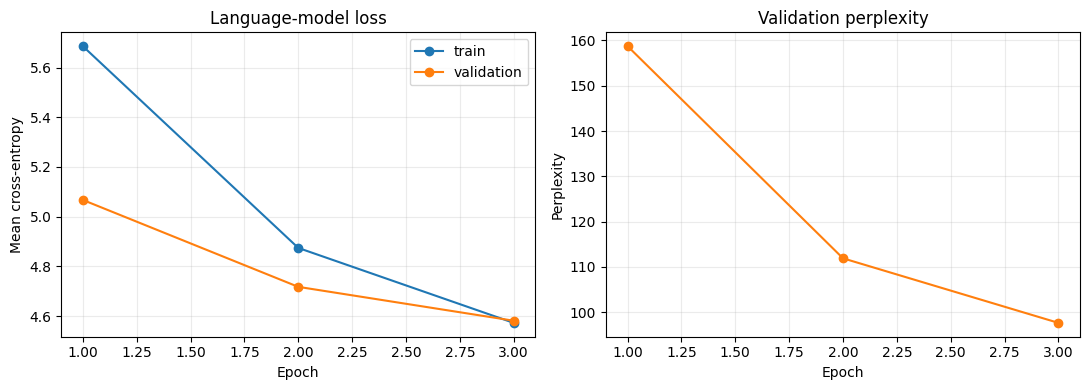

Saved: /content/a1_rnn_lm/outputs/training_curves_full.png


In [29]:
# Plot loss and perplexity after training.
epochs = [row["epoch"] for row in history]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs, [row["train_loss"] for row in history], marker="o", label="train")
axes[0].plot(epochs, [row["val_loss"] for row in history], marker="o", label="validation")
axes[0].set(xlabel="Epoch", ylabel="Mean cross-entropy", title="Language-model loss")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(epochs, [row["val_perplexity"] for row in history], marker="o", color="tab:orange")
axes[1].set(xlabel="Epoch", ylabel="Perplexity", title="Validation perplexity")
axes[1].grid(alpha=0.25)

fig.tight_layout()
curve_file = OUTPUT_DIR / f"training_curves_{RUN_MODE}.png"
fig.savefig(curve_file, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", curve_file)


# Part 5 - Evaluation and analysis

The next cells demonstrate model reuse, next-token prediction, a final validation perplexity calculation, nearest neighbors in the learned embedding space, and a two-dimensional embedding visualization.


In [30]:
# This is the pattern to reuse a saved model without retraining.
loaded_tokenizer = A1Tokenizer.from_file(MODEL_DIR / "tokenizer.pkl")
loaded_model = A1RNNModel.from_pretrained(MODEL_DIR)
loaded_model.to(trainer.select_device())
loaded_model.eval()

assert len(loaded_tokenizer) == len(tokenizer)
print("Reloaded the saved tokenizer and model successfully.")


Loading weights:   0%|          | 0/11 [00:00<?, ?it/s]

Reloaded the saved tokenizer and model successfully.


In [31]:
@torch.no_grad()
def predict_next_words(model, tokenizer, prompt, top_k=10, device=None):
    device = device or next(model.parameters()).device
    encoded = tokenizer(prompt, truncation=True, padding=False, return_tensors="pt")
    # The tokenizer appends EOS. Remove it so the last real prompt position predicts the continuation.
    input_ids = encoded["input_ids"][:, :-1].to(device)
    output = model(input_ids=input_ids)
    probabilities = torch.softmax(output.logits[0, -1], dim=-1)

    # Request extra candidates, then omit structural special tokens from the display.
    special_ids = {tokenizer.pad_token_id, tokenizer.bos_token_id, tokenizer.eos_token_id}
    values, indices = torch.topk(probabilities, k=min(top_k + len(special_ids), len(tokenizer)))
    predictions = []
    for probability, index in zip(values.tolist(), indices.tolist()):
        if index in special_ids:
            continue
        predictions.append((tokenizer.int_to_str[index], probability))
        if len(predictions) == top_k:
            break
    return predictions


for prompt in ["She lives in San", "The capital of Sweden is", "The meaning of life is"]:
    print("\nPrompt:", prompt)
    for word, probability in predict_next_words(loaded_model, loaded_tokenizer, prompt, top_k=8):
        print(f"  {word:<18} {probability:.4f}")



Prompt: She lives in San
  francisco          0.4404
  diego              0.2159
  <UNK>              0.1204
  cristóbal          0.0206
  vegas              0.0122
  jose               0.0095
  salvador           0.0084
  antonio            0.0067

Prompt: The capital of Sweden is
  the                0.1713
  a                  0.0993
  located            0.0637
  divided            0.0492
  also               0.0414
  an                 0.0322
  <UNK>              0.0274
  one                0.0214

Prompt: The meaning of life is
  the                0.1315
  a                  0.0959
  that               0.0848
  <UNK>              0.0339
  ``                 0.0310
  an                 0.0306
  to                 0.0257
  not                0.0229


In [32]:
# Perplexity is exp(mean token-level cross-entropy), with padding positions excluded.
final_metrics = trainer.evaluate(device=trainer.select_device())
print(json.dumps(final_metrics, indent=2))

with (OUTPUT_DIR / f"final_metrics_{RUN_MODE}.json").open("w", encoding="utf-8") as handle:
    json.dump(final_metrics, handle, indent=2)


Validation:   0%|          | 0/280 [00:00<?, ?it/s]

{
  "loss": 4.5812815617390985,
  "perplexity": 97.63944503674523,
  "tokens": 1154818
}


In [33]:
@torch.no_grad()
def nearest_neighbors(model, tokenizer, word, n_neighbors=8):
    word = word.lower()
    if word not in tokenizer.str_to_int:
        raise KeyError(f"{word!r} is not in the retained vocabulary.")

    matrix = model.embedding.weight.detach()
    query_id = tokenizer.str_to_int[word]
    scores = F.cosine_similarity(matrix, matrix[query_id].unsqueeze(0), dim=1)

    excluded = {
        query_id,
        tokenizer.pad_token_id,
        tokenizer.unk_token_id,
        tokenizer.bos_token_id,
        tokenizer.eos_token_id,
    }
    values, indices = scores.topk(min(n_neighbors + len(excluded), len(tokenizer)))
    neighbors = []
    for score, idx in zip(values.tolist(), indices.tolist()):
        if idx in excluded:
            continue
        neighbors.append((tokenizer.int_to_str[idx], score))
        if len(neighbors) == n_neighbors:
            break
    return neighbors


for query in ["sweden", "music", "large", "three"]:
    if query in loaded_tokenizer.str_to_int:
        print(f"\nNearest neighbors of {query!r}:")
        for neighbor, similarity in nearest_neighbors(loaded_model, loaded_tokenizer, query):
            print(f"  {neighbor:<18} {similarity:.3f}")



Nearest neighbors of 'sweden':
  france             0.927
  germany            0.911
  russia             0.908
  britain            0.896
  italy              0.896
  turkey             0.892
  india              0.891
  burma              0.887

Nearest neighbors of 'music':
  ballet             0.788
  poetry             0.772
  entertainment      0.759
  artwork            0.752
  concert            0.739
  broadway           0.724
  dubbing            0.721
  museums            0.720

Nearest neighbors of 'large':
  small              0.922
  sizable            0.851
  vast               0.828
  sizeable           0.822
  larger             0.821
  smaller            0.811
  substantial        0.810
  massive            0.788

Nearest neighbors of 'three':
  four               0.950
  five               0.946
  two                0.941
  six                0.933
  eight              0.928
  twenty-six         0.898
  ten                0.895
  eleven             0.892


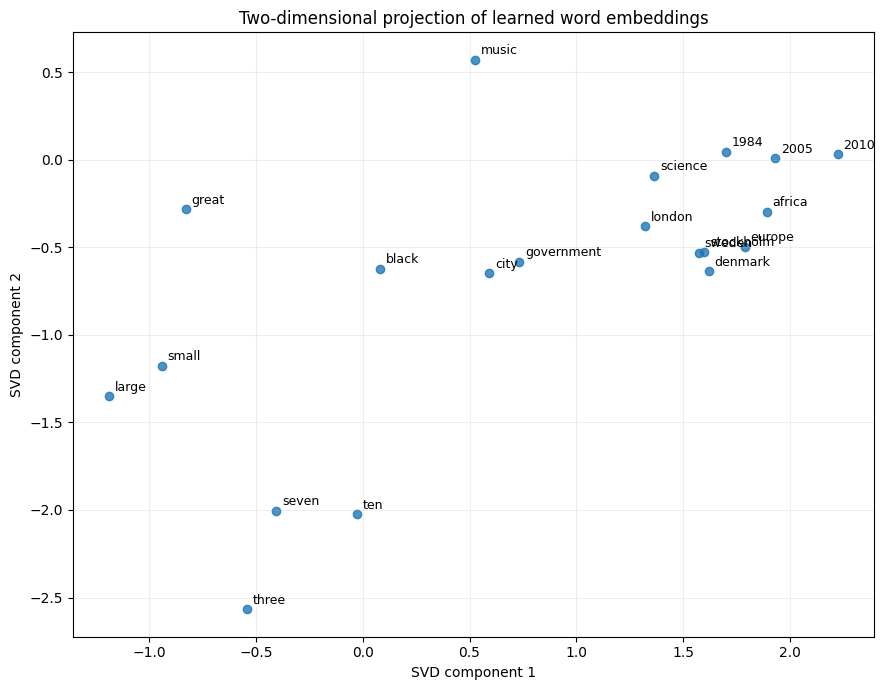

Saved: /content/a1_rnn_lm/outputs/embedding_projection_full.png


In [34]:
def plot_embedding_words(model, tokenizer, words, output_file):
    words = [word.lower() for word in words if word.lower() in tokenizer.str_to_int]
    if len(words) < 3:
        raise ValueError("At least three requested words must be in the vocabulary.")

    ids = [tokenizer.str_to_int[word] for word in words]
    vectors = model.embedding.weight.detach().cpu().numpy()[ids]
    points = TruncatedSVD(n_components=2, random_state=SEED).fit_transform(vectors)

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.scatter(points[:, 0], points[:, 1], color="tab:blue", alpha=0.8)
    for word, (x, y) in zip(words, points):
        ax.annotate(word, (x, y), xytext=(4, 4), textcoords="offset points", fontsize=9)
    ax.set_title("Two-dimensional projection of learned word embeddings")
    ax.set_xlabel("SVD component 1")
    ax.set_ylabel("SVD component 2")
    ax.grid(alpha=0.2)
    fig.tight_layout()
    fig.savefig(output_file, dpi=170, bbox_inches="tight")
    plt.show()


plot_words = [
    "sweden", "denmark", "europe", "africa", "london", "stockholm",
    "large", "small", "great", "black", "three", "seven", "ten",
    "1984", "2005", "2010", "music", "science", "government", "city",
]
embedding_plot_file = OUTPUT_DIR / f"embedding_projection_{RUN_MODE}.png"
plot_embedding_words(loaded_model, loaded_tokenizer, plot_words, embedding_plot_file)
print("Saved:", embedding_plot_file)
